<a href="https://colab.research.google.com/github/David-S-Hunsicker/ml/blob/main/RL_part_2_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this assignment, we will use
* causality return
* value baseline

to make policy gradient update in the Lunar lander environment.

Gymnasium environment reference: [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

You can modify from the trainer implementation in [class demo](https://drive.google.com/file/d/1MmlBMyiFZos_16YzoiWKbCkOZs_fOR12/view).
* Complete the return and advantage implementation.
* Update the trainer to call appropriate return/advantage computation for policy gradient updates.
* Implement the critic network, its loss function and back propagation logic.

Reinforcement learning is sensitive to hyperparameters. Lunar Lander environment is considered solved with 200 episode return. Our simple implementations should generally be able to reach > 100 returns. Test hyperparameters such as learning rate, max episode length, number of epochs, number of steps per epoch, return/advantage computation to see what tweeks help.



## Notebook Checklist

- [ ] Set up the LunarLander environment and Gymnasium dependencies.
- [ ] Implement `reinforce_returns`.
- [ ] Implement `causality`.
- [ ] Implement `compute_advantage`.
- [ ] Wire the trainer to choose the right return or advantage method.
- [ ] Implement the policy network.
- [ ] Implement the critic/value network.
- [ ] Implement the critic loss and optimizer step.
- [ ] Finish the training loop in `train()`.
- [ ] Finish the rollout and evaluation loop in `eval()`.
- [ ] Add logging for episode return, policy loss, and value loss.
- [ ] Plot training progress for comparison across methods.
- [ ] Run a smoke test to confirm the environment and updates work.
- [ ] Tune hyperparameters if learning is unstable or too slow.

In [78]:
# Install the Box2D and Gymnasium packages needed to run LunarLander in this notebook.
# The swig dependency is required by Box2D on this environment.
!apt-get install swig > /dev/null 2>&1
!pip install gymnasium > /dev/null 2>&1
!pip install gymnasium[box2d] > /dev/null 2>&1
!pip install gymnasium[classic-control]

In [79]:
# Load the libraries used for environment interaction, numerical work,
# plotting, and building the policy/value networks.

import pandas as pd
import gymnasium as gym
import numpy as np
import random
import seaborn as sns

from IPython import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.optim import Adam
import numpy as np
from gymnasium.spaces import Discrete, Box

In [80]:
def reinforce_returns(episode_rewards):
    """Return full-episode return for each timestep.

    Args:
        episode_rewards: Rewards for one episode.

    Returns:
        List[float]: Constant sequence where each element is sum(episode_rewards).
    """
    total_return = sum(episode_rewards)
    return [total_return for _ in episode_rewards]



def causality(episode_rewards):
    """Return reward-to-go for each timestep.

    Args:
        episode_rewards: Rewards for one episode.

    Returns:
        List[float]: Sequence where element t is sum(rewards[t:]).
    """
    returns = [0] * len(episode_rewards)
    running_return = 0
    for index in range(len(episode_rewards) - 1, -1, -1):
        running_return += episode_rewards[index]
        returns[index] = running_return
    return returns



def compute_advantage(episode_returns, episode_values):
    """Compute advantage values.

    Args:
        episode_returns: Return targets per timestep.
        episode_values: Value estimates per timestep.

    Returns:
        torch.Tensor: Advantage per timestep.
    """
    returns_tensor = torch.as_tensor(episode_returns, dtype=torch.float32)
    values_tensor = torch.as_tensor(episode_values, dtype=torch.float32)
    return returns_tensor - values_tensor

In [81]:
# Build a simple feedforward network with configurable hidden layers.
# Used as the backbone for both the policy and the critic.
def make_mlp(layer_sizes, activation=nn.Tanh):
    """Build an MLP with linear output layer.

    Args:
        layer_sizes: Layer widths including input and output dimensions.
        activation: Activation class for hidden layers.

    Returns:
        nn.Sequential: Feedforward network.
    """
    layers = []
    for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        layers.append(nn.Linear(in_size, out_size))
        layers.append(activation())
    layers.pop()  # remove the last activation so the output is raw logits/values
    return nn.Sequential(*layers)


# Policy network: takes an observation and outputs a logit for each action.
# A Categorical distribution over those logits is used to sample actions and
# compute log-probabilities for the policy-gradient loss.
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_sizes: list[int]):
        super().__init__()
        self.net = make_mlp([obs_dim] + hidden_sizes + [act_dim])

    def forward(self, obs):
        """Return action distribution for observations."""
        return Categorical(logits=self.net(obs))

    def get_action(self, obs):
        """Sample one action and return (action, log_prob)."""
        dist = self(obs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


# Critic (value) network: takes an observation and outputs a scalar estimate
# of the expected return from that state.  Used only in the 'advantage' method.
class CriticNetwork(nn.Module):
    """State-value function approximator."""

    def __init__(self, obs_dim: int, hidden_sizes: list[int]):
        super().__init__()
        self.net = make_mlp([obs_dim] + hidden_sizes + [1])

    def forward(self, obs):
        """Return value estimate per observation."""
        return self.net(obs).squeeze(-1)

In [82]:
class PolicyGradientTrainer():
    """Train policy-gradient agents on Gymnasium environments."""

    def __init__(self, env_name: str = 'LunarLander-v3', lr: float = 1e-2,
                 value_lr: float = 1e-3, max_eps_length: int = 500,
                 epochs: int = 50, n_steps_per_epoch: int = 5000,
                 hidden_sizes: list[int] = [32], method: str = 'reinforce',
                 verbose: bool = False):
        """Initialize training configuration.

        Args:
            env_name: Gymnasium environment id.
            lr: Policy optimizer learning rate.
            value_lr: Critic optimizer learning rate.
            max_eps_length: Max steps per episode rollout.
            epochs: Number of training epochs.
            n_steps_per_epoch: Minimum rollout steps collected each epoch.
            hidden_sizes: Shared hidden-layer sizes for MLP networks.
            method: One of {'reinforce', 'causality', 'advantage'}.
            verbose: Whether to print periodic progress.
        """
        if method not in {'reinforce', 'causality', 'advantage'}:
            raise ValueError('Unsupported method.')

        self.env_name = env_name
        self.lr = lr
        self.value_lr = value_lr
        self.max_eps_length = max_eps_length
        self.epochs = epochs
        self.n_steps_per_epoch = n_steps_per_epoch
        self.hidden_sizes = hidden_sizes
        self.method = method
        self.verbose = verbose
        self.return_fn = reinforce_returns if method == 'reinforce' else causality

    # Train the policy model and return per-epoch mean episode reward.
    def train(self):
        # Create the environment and infer observation/action dimensions.
        env = gym.make(self.env_name)
        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n

        # Build the policy network and its optimizer.
        policy = PolicyNetwork(obs_dim, act_dim, self.hidden_sizes)
        policy_optimizer = Adam(policy.parameters(), lr=self.lr)

        # Build the critic and its optimizer only when using the advantage method.
        if self.method == 'advantage':
            critic = CriticNetwork(obs_dim, self.hidden_sizes)
            critic_optimizer = Adam(critic.parameters(), lr=self.value_lr)

        episode_returns = []
        epoch_mean_returns = []

        for epoch in range(self.epochs):
            # Collect experience until we have enough steps for this epoch.
            batch_obs, batch_log_probs, batch_returns = [], [], []
            batch_values = []  # only populated for 'advantage'
            ep_rewards = []
            epoch_episode_returns = []
            obs, _ = env.reset()
            episode_return = 0

            while len(batch_obs) < self.n_steps_per_epoch:
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
                action, log_prob = policy.get_action(obs_tensor)

                # Record value estimate before stepping the environment.
                if self.method == 'advantage':
                    with torch.no_grad():
                        value = critic(obs_tensor).item()
                    batch_values.append(value)

                obs, reward, terminated, truncated, _ = env.step(action)
                ep_rewards.append(reward)
                batch_obs.append(obs_tensor)
                batch_log_probs.append(log_prob)
                episode_return += reward

                done = terminated or truncated or len(ep_rewards) >= self.max_eps_length
                if done:
                    # Compute per-step returns for this finished episode.
                    ep_returns = self.return_fn(ep_rewards)
                    batch_returns.extend(ep_returns)
                    episode_returns.append(episode_return)
                    epoch_episode_returns.append(episode_return)
                    ep_rewards = []
                    episode_return = 0
                    obs, _ = env.reset()

            # Finalize a partially collected episode when step budget ends mid-episode.
            if ep_rewards:
                ep_returns = self.return_fn(ep_rewards)
                batch_returns.extend(ep_returns)
                episode_returns.append(episode_return)
                epoch_episode_returns.append(episode_return)

            # Build tensors for the policy-gradient loss calculation.
            returns_tensor = torch.as_tensor(batch_returns, dtype=torch.float32)

            if self.method == 'advantage':
                # Advantage = return - critic's value estimate.
                advantages = compute_advantage(batch_returns, batch_values)
                weights = advantages
            else:
                weights = returns_tensor

            # Policy loss: -mean(log_prob * weight). Negative because Adam minimises.
            log_probs_tensor = torch.stack(batch_log_probs)
            policy_loss = -(log_probs_tensor * weights).mean()

            policy_optimizer.zero_grad()
            policy_loss.backward()
            policy_optimizer.step()

            # Critic update: minimise MSE between predicted values and actual returns.
            if self.method == 'advantage':
                obs_tensor_batch = torch.stack(batch_obs)
                value_preds = critic(obs_tensor_batch)
                critic_loss = ((value_preds - returns_tensor) ** 2).mean()

                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

            epoch_mean_return = float(np.mean(epoch_episode_returns)) if epoch_episode_returns else float('nan')
            epoch_mean_returns.append(epoch_mean_return)

            if self.verbose:
                print(f"Epoch {epoch+1}/{self.epochs} | mean return: {epoch_mean_return:.1f}")

        env.close()
        self.policy = policy
        self.episode_returns = episode_returns
        self.epoch_mean_returns = epoch_mean_returns
        return epoch_mean_returns

    # Evaluate the policy model by acting in the environment for one episode.
    def eval(self, render_every: int | None = None):
        """Run one evaluation episode and return total reward.

        Args:
            render_every: Render every N steps when set to a positive integer.
                Use None to disable rendering and keep notebook plots visible.
        """
        env = gym.make(self.env_name, render_mode='rgb_array')
        obs, _ = env.reset()
        total_reward = 0
        step = 0
        done = False

        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
            with torch.no_grad():
                action, _ = self.policy.get_action(obs_tensor)

            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

            # Render only when explicitly enabled.
            if render_every is not None and render_every > 0 and step % render_every == 0:
                if step > 0:
                    display.clear_output(wait=True)
                frame = env.render()
                plt.figure(figsize=(6, 4))
                plt.imshow(frame)
                plt.axis('off')
                display.display(plt.gcf())
                plt.close()
            step += 1

        env.close()
        print(f"Eval episode return: {total_reward:.1f}")
        return total_reward

Epoch 1/3000 | mean return: -159.0
Epoch 2/3000 | mean return: -144.2
Epoch 3/3000 | mean return: -155.6
Epoch 4/3000 | mean return: -181.8
Epoch 5/3000 | mean return: -219.5
Epoch 6/3000 | mean return: -146.7
Epoch 7/3000 | mean return: -213.8
Epoch 8/3000 | mean return: -201.3
Epoch 9/3000 | mean return: -99.5
Epoch 10/3000 | mean return: -161.8
Epoch 11/3000 | mean return: -169.4
Epoch 12/3000 | mean return: -163.3
Epoch 13/3000 | mean return: -201.6
Epoch 14/3000 | mean return: -159.1
Epoch 15/3000 | mean return: -156.9
Epoch 16/3000 | mean return: -234.2
Epoch 17/3000 | mean return: -170.2
Epoch 18/3000 | mean return: -131.6
Epoch 19/3000 | mean return: -205.5
Epoch 20/3000 | mean return: -188.6
Epoch 21/3000 | mean return: -131.5
Epoch 22/3000 | mean return: -170.4
Epoch 23/3000 | mean return: -142.4
Epoch 24/3000 | mean return: -192.1
Epoch 25/3000 | mean return: -111.2
Epoch 26/3000 | mean return: -131.0
Epoch 27/3000 | mean return: -156.7
Epoch 28/3000 | mean return: -145.4
Ep

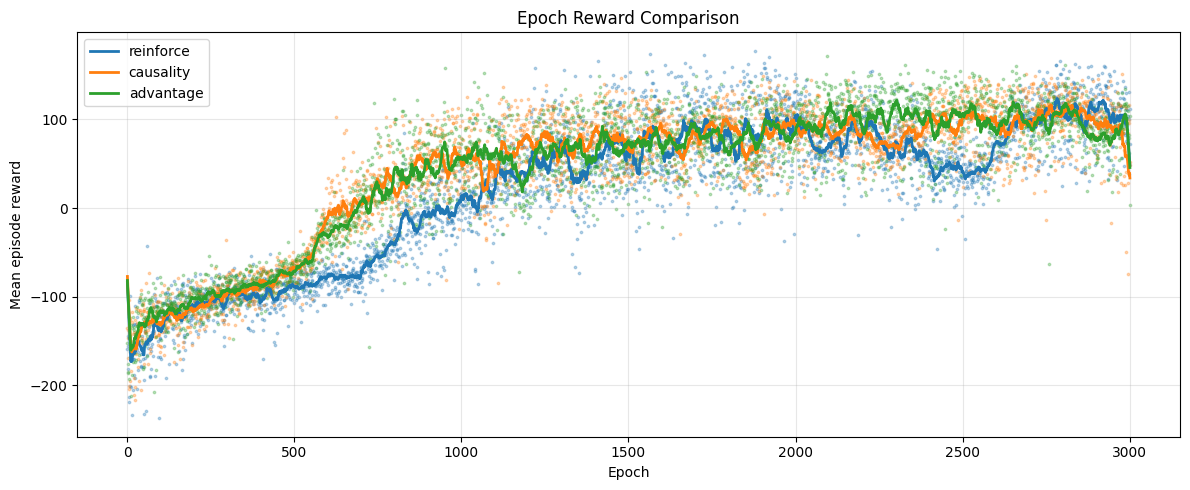

In [86]:
def _smooth(values, window=20):
    """Rolling mean with window capped to signal length."""
    w = min(window, len(values))
    return np.convolve(values, np.ones(w) / w, mode='same')


def run_experiment(method='causality', epochs=5, n_steps_per_epoch=1500, hidden_sizes=[64, 64],
                   lr=1e-3, value_lr=1e-3, max_eps_length=500, verbose=True,
                   eval_render_every=None, show_plot=True):
    """Train one policy-gradient configuration and plot reward per epoch.

    Args:
        method: One of {'reinforce', 'causality', 'advantage'}.
        epochs: Number of training epochs.
        n_steps_per_epoch: Environment steps collected each epoch.
        hidden_sizes: Hidden-layer widths for policy/value networks.
        lr: Policy learning rate.
        value_lr: Critic learning rate.
        max_eps_length: Max steps per episode.
        verbose: Print trainer progress.
        eval_render_every: Render frequency for eval; None keeps plots visible.
        show_plot: Whether to display the per-method reward chart.

    Returns:
        tuple[PolicyGradientTrainer, list[float], float]:
            Trained trainer, mean reward per epoch, and evaluation return.
    """
    trainer = PolicyGradientTrainer(
        method=method,
        epochs=epochs,
        n_steps_per_epoch=n_steps_per_epoch,
        hidden_sizes=hidden_sizes,
        lr=lr,
        value_lr=value_lr,
        max_eps_length=max_eps_length,
        verbose=verbose,
    )

    epoch_rewards = trainer.train()

    if show_plot:
        xs = np.arange(1, len(epoch_rewards) + 1)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.scatter(xs, epoch_rewards, s=4, alpha=0.5, label=f'{method}')
        ax.plot(xs, _smooth(epoch_rewards), linewidth=1.5, label=f'{method} (20-epoch avg)')
        ax.set_title(f'Epoch Reward Curve ({method})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Mean episode reward')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.show()

    eval_return = trainer.eval(render_every=eval_render_every)
    return trainer, epoch_rewards, eval_return


def compare_methods(methods=('reinforce', 'causality', 'advantage'), **experiment_kwargs):
    """Train multiple methods and overlay their epoch reward curves.

    Args:
        methods: Methods to evaluate.
        **experiment_kwargs: Shared keyword args forwarded to run_experiment().

    Returns:
        dict[str, dict[str, object]]: Per-method trainer, rewards, and eval return.
    """
    results = {}
    fig, ax = plt.subplots(figsize=(12, 5))

    for method in methods:
        trainer, epoch_rewards, eval_return = run_experiment(
            method=method,
            show_plot=False,
            **experiment_kwargs,
        )
        results[method] = {
            'trainer': trainer,
            'epoch_rewards': epoch_rewards,
            'eval_return': eval_return,
        }
        xs = np.arange(1, len(epoch_rewards) + 1)
        ax.scatter(xs, epoch_rewards, s=3, alpha=0.3)
        ax.plot(xs, _smooth(epoch_rewards), linewidth=2, label=f'{method}')

    ax.set_title('Epoch Reward Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean episode reward')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return results


RUN_SMOKE_TEST = True
if RUN_SMOKE_TEST:
    comparison_results = compare_methods(
        methods=('reinforce', 'causality', 'advantage'),
        epochs=3000,
        n_steps_per_epoch=700,
        hidden_sizes=[64, 64],
        lr=1e-3,
        value_lr=1e-3,
        verbose=True,
        eval_render_every=None,
    )